In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import json
import matplotlib.pyplot as plt

seed = 5
np.random.seed(seed)

result_path = Path("diagrams", "feature_weights_importances")
result_path.mkdir(exist_ok=True)

In [2]:
bias_type = "less_positive_class"
bias_strength = "0.1"
data_set_name = "breast_cancer"

In [3]:
feature_names = [
    "Clump Thickness",
    "Cell Size",
    "Cell Shape",
    "Marginal Adhesion",
    "Epithelial Cell Size",
    "Bare Nuclei",
    "Bland Chromatin",
    "Normal Nucleoli",
    "Mitoses",]

In [4]:
method_name = "fw-mrs-temperature"
data_path = Path("..", "results", "temperature_comparison", data_set_name, bias_type, bias_strength, 
                 method_name, "feature_weights/weights.json")
with open(data_path, 'r') as file:
    all_feature_weights_rf = json.load(file)

data_path = Path("..", "results", "temperature_comparison", data_set_name, bias_type, bias_strength, 
                 method_name, "feature_importances/feature_importances.json")
with open(data_path, 'r') as file:
    all_feature_importances_rf = json.load(file)

FileNotFoundError: [Errno 2] No such file or directory: '../results/temperature_comparison/breast_cancer/less_positive_class/0.1/fw-mrs-temperature/feature_weights/weights.json'

In [ ]:
hyperparameter = "0.0"
feature_weights_dict = {temperature: [] for temperature in all_feature_weights_rf[0].keys()}
feature_importance_dict = {temperature: [] for temperature in all_feature_importances_rf[0].keys()}

feature_weights_dict_std = {temperature: [] for temperature in all_feature_weights_rf[0].keys()}
feature_importance_dict_std = {temperature: [] for temperature in all_feature_importances_rf[0].keys()}

for temperature in all_feature_weights_rf[0].keys():
    for weights_values, importance_values in zip(all_feature_weights_rf, all_feature_importances_rf):
        weights_temperature_values = weights_values[temperature][hyperparameter]
        feature_weights_dict[temperature].append(weights_temperature_values)

        weights_importance_values = importance_values[temperature][hyperparameter]
        feature_importance_dict[temperature].append(weights_importance_values)

    feature_weights_dict_std[temperature] = np.std(feature_weights_dict[temperature], axis=0)
    feature_importance_dict_std[temperature] = np.std(feature_importance_dict[temperature], axis=0)
    
    feature_weights_dict[temperature] = np.mean(feature_weights_dict[temperature], axis=0)
    feature_importance_dict[temperature] = np.mean(feature_importance_dict[temperature], axis=0)


In [ ]:
weights_df = pd.DataFrame(feature_weights_dict).T
weights_df["Temperature"] = weights_df.index
weights_df.columns = feature_names +  ["Temperature"]
weights_df = pd.melt(weights_df, id_vars="Temperature")

importance_df = pd.DataFrame(feature_importance_dict).T
importance_df["Temperature"] = importance_df.index
importance_df.columns = feature_names +  ["Temperature"]
importance_df = pd.melt(importance_df, id_vars="Temperature")

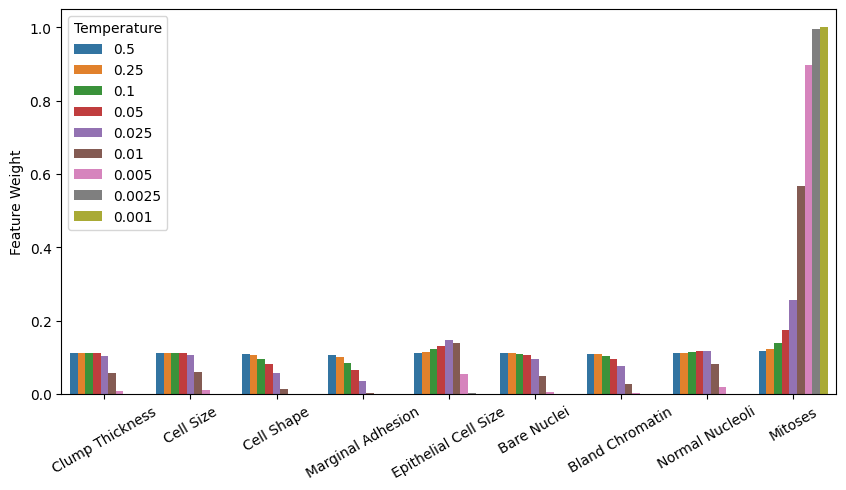

In [ ]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=weights_df, x="variable",  y="value", hue="Temperature")
ax.set(xlabel='', ylabel='Feature Weight')
plt.xticks(rotation=30)

plt.savefig("diagrams/feature_weights.pdf", bbox_inches='tight')

In [ ]:
importance_df

,Temperature,variable,value
0,0.5,Clump Thickness,0.030916
1,0.25,Clump Thickness,0.030916
2,0.1,Clump Thickness,0.030916
3,0.05,Clump Thickness,0.030916
4,0.025,Clump Thickness,0.030916
...,...,...,...
76,0.025,Mitoses,0.008134
77,0.01,Mitoses,0.008134
78,0.005,Mitoses,0.008134
79,0.0025,Mitoses,0.008134


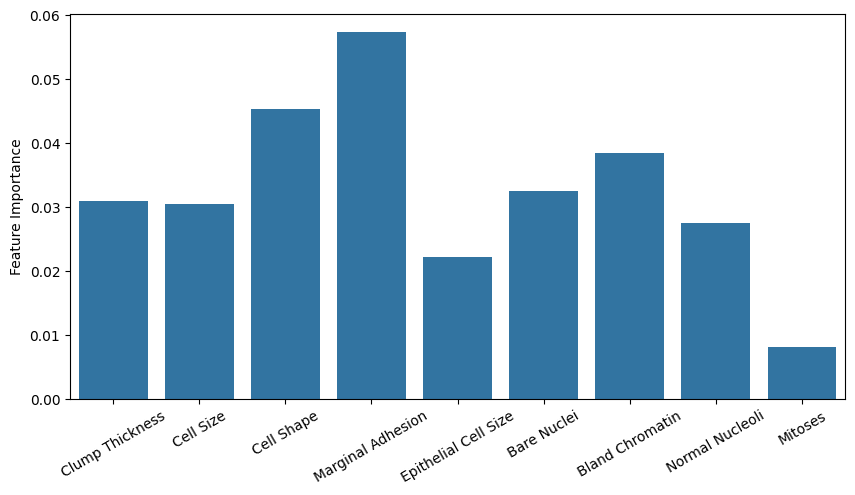

In [ ]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=importance_df, x="variable", y="value", errorbar=None)
ax.set(xlabel='', ylabel='Feature Importance')
plt.xticks(rotation=30)
plt.savefig("diagrams/feature_importance.pdf", bbox_inches='tight')

In [ ]:
n_variables = len(weights_df["variable"].unique())
max_features = int(np.sqrt(n_variables))
drawn_features = np.random.choice(weights_df["variable"].unique(), size=max_features, replace=False)

/tmp/ipykernel_360803/110274438.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=probabilities, x="variable", y="p", palette=clrs)


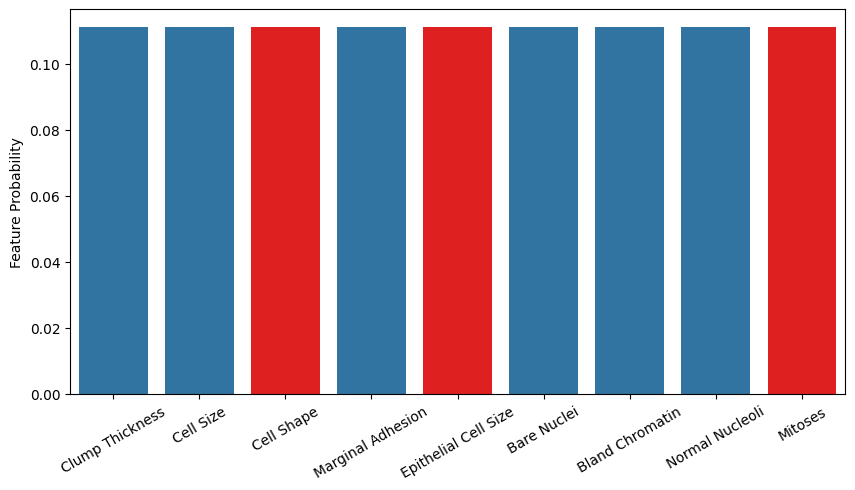

In [ ]:
plt.figure(figsize=(10, 5))
probability = 1.0 / n_variables
probabilities = pd.DataFrame({"variable": feature_names, "p": np.ones(len(feature_names)) * probability})
ax = sns.barplot(data=probabilities, x="variable", y="p")
ax.set(xlabel='', ylabel='Feature Probability')
plt.xticks(rotation=30)
plt.savefig("diagrams/uniform_random_forest.pdf", bbox_inches='tight')

clrs = ['red' if feature in drawn_features else "#1f77b4" for feature in weights_df["variable"].unique() ]
ax = sns.barplot(data=probabilities, x="variable", y="p", palette=clrs)
ax.set(xlabel='', ylabel='Feature Probability')
plt.xticks(rotation=30)
plt.savefig("diagrams/uniform_chosen_random_forest.pdf", bbox_inches='tight')

/home/thauptmann/.virtualenvs/feature_weighting/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/tmp/ipykernel_360803/3281733315.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=probabilities, x="variable", y="p", palette=clrs)


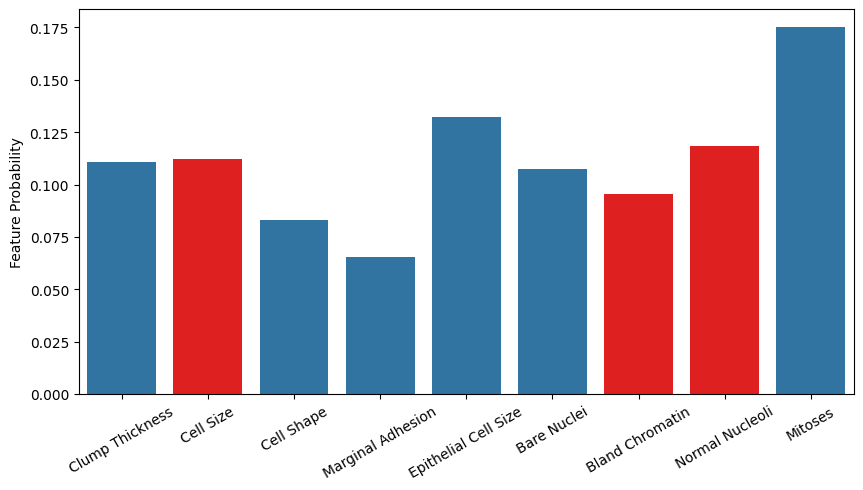

In [ ]:
drawn_features = np.random.choice(weights_df["variable"].unique(), size=max_features,
                                   p=weights_df[(weights_df["Temperature"] == "0.05")]["value"], replace=False)

plt.figure(figsize=(10, 5))
probability = weights_df[(weights_df["Temperature"] == "0.05")][["value", "variable"]]
weight_sum = np.sum(probability)["value"]
probability["value"] = probability["value"] / weight_sum
probabilities = pd.DataFrame({"variable": feature_names, "p": np.zeros(len(feature_names))})
probabilities["p"] = probability["value"].values
tmp_data_weights = importance_df.copy()
ax = sns.barplot(data=probabilities, x="variable", y="p")
ax.set(xlabel='', ylabel='Feature Probability')
plt.xticks(rotation=30)
plt.savefig("diagrams/feature_weighted_random_forest.pdf", bbox_inches='tight')

clrs = ['red' if feature in drawn_features else "#1f77b4" for feature in weights_df["variable"].unique() ]
ax = sns.barplot(data=probabilities, x="variable", y="p", palette=clrs)
ax.set(xlabel='', ylabel='Feature Probability')
plt.xticks(rotation=30)
plt.savefig("diagrams/feature_weighted_chosen_random_forest.pdf", bbox_inches='tight')